In [2]:
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm
import networkx as nx
from collections import defaultdict
from scipy.optimize import minimize

mpl.rcParams['xtick.labelsize'] = 20
mpl.rcParams['ytick.labelsize'] = 20
mpl.rcParams['font.size'] = 20
mpl.rcParams['figure.autolayout'] = False
mpl.rcParams['axes.linewidth'] = 3
mpl.rcParams['axes.titlesize'] = 20
mpl.rcParams['axes.labelsize'] = 20
mpl.rcParams['lines.linewidth'] = 2.2
mpl.rcParams['lines.markersize'] = 5
mpl.rcParams['lines.markeredgewidth'] = 1.2
mpl.rcParams['errorbar.capsize'] = 5
mpl.rcParams['xtick.major.width'] = 3
mpl.rcParams['xtick.major.size'] = 10
mpl.rcParams['ytick.major.width'] = 3
mpl.rcParams['ytick.major.size'] = 8
mpl.rcParams['xtick.minor.width'] = 1.5
mpl.rcParams['xtick.minor.size'] = 6
mpl.rcParams['ytick.minor.width'] = 1.5
mpl.rcParams['ytick.minor.size'] = 6
mpl.rcParams['legend.fontsize'] = 14
mpl.rcParams['mathtext.fontset'] = 'dejavusans'
mpl.rcParams['font.family'] = 'sans-serif'
cm_colors = plt.get_cmap('Set2')


Text(0, 0.5, 'Fidelity')

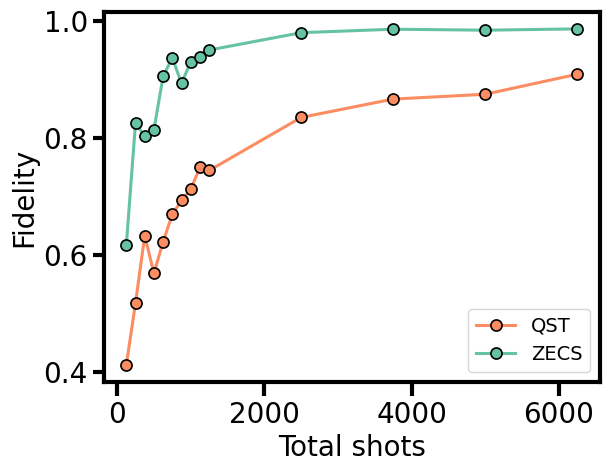

In [18]:
results = np.load("./Data/qst_results_qaoa_5q.npy", allow_pickle=True).item()
colors= plt.get_cmap("Set2")
G = results["G"]
shots_list = results["shots_list"]
fig, ax = plt.subplots()
num_qubits = G.number_of_nodes()
ax.plot(np.array(shots_list)*num_qubits**3, results["F_qst"], marker="o", label="QST", markersize=8, markeredgecolor="black", color=colors(1))
ax.plot(np.array(shots_list)*num_qubits**3, results["F_zecs"], marker="o", label="ZECS", markersize=8, markeredgecolor="black", color=colors(0))
ax.legend()
ax.set_xlabel("Total shots")
ax.set_ylabel("Fidelity")
# fig.savefig("./Figures/QST_LRQAOA_5q_p10.pdf", bbox_inches="tight", transparent=True)

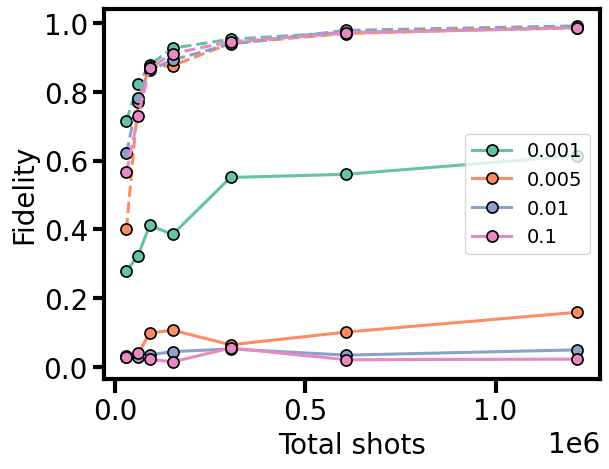

In [26]:
fig, ax = plt.subplots()

for i, error in enumerate([1e-3, 5e-3, 10e-3,100e-3]):

    results = np.load(f"./Data/qst_results_qaoa_5q_p20_noise_{error}.npy", allow_pickle=True).item()
    colors= plt.get_cmap("Set2")
    G = results["G"]
    shots_list = results["shots_list"]
    num_qubits = G.number_of_nodes()
    ax.plot(np.array(shots_list)*num_qubits**3, results["F_qst"], marker="o", markersize=8, markeredgecolor="black", color=colors(i), label=error)
    ax.plot(np.array(shots_list)*num_qubits**3, results["F_zecs"], marker="o", markersize=8, markeredgecolor="black", color=colors(i), linestyle="--")
    ax.legend()
    ax.set_xlabel("Total shots")
    ax.set_ylabel("Fidelity")
    # fig.savefig("./Figures/QST_LRQAOA_5q_p10.pdf", bbox_inches="tight", transparent=True)

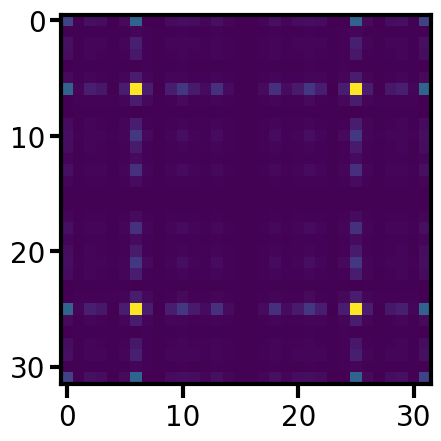

In [23]:
fig, ax = plt.subplots()
ax.imshow(results["p_ideal"].real)

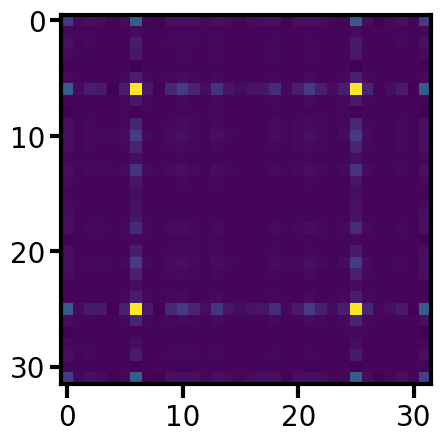

In [24]:
fig, ax = plt.subplots()
ax.imshow(results[shots_list[-1]]["p_zecs"].real)

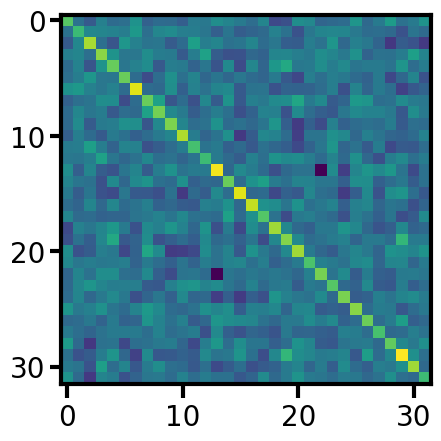

In [25]:
fig, ax = plt.subplots()
ax.imshow(results[shots_list[-1]]["p_qst"].real)